In [3]:
import pandas as pd


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/data/Advertising Budget and Sales.csv')

df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Data Preperation

In [6]:
df = df.rename(columns={"Sales ($)": "Sales(Units)"})

df.columns

Index(['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)',
       'Newspaper Ad Budget ($)', 'Sales(Units)'],
      dtype='object')

In [7]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Missing Values:")
print(df.isnull().sum())

df = df.drop_duplicates()

df.info()

Missing Values:
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales(Units)               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales(Units)             200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Data Engineering

In [8]:
# Creating total advertising budget column

df["Total_Ad_Budget"] = (
    df["TV Ad Budget ($)"] +
    df["Radio Ad Budget ($)"] +
    df["Newspaper Ad Budget ($)"]
)

df = df.round(1)

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales(Units),Total_Ad_Budget
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0


this column will allow me to see what each company is spending on all three ad budgets. this is probably the most important added column because of the amount of things I need to know what the total for all of these ad budgets.

In [9]:
# creating a channel share columns for each ad

df["TV_Share(%)"] = df["TV Ad Budget ($)"] / df["Total_Ad_Budget"]
df["Radio_Share(%)"] = df["Radio Ad Budget ($)"] / df["Total_Ad_Budget"]
df["Newspaper_Share(%)"] = df["Newspaper Ad Budget ($)"] / df["Total_Ad_Budget"]

# round share columns and make them percentages

share_cols = ["TV_Share(%)", "Radio_Share(%)", "Newspaper_Share(%)"]

df[share_cols] = (df[share_cols] * 100).round(2)

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales(Units),Total_Ad_Budget,TV_Share(%),Radio_Share(%),Newspaper_Share(%)
0,230.1,37.8,69.2,22.1,337.1,68.26,11.21,20.53
1,44.5,39.3,45.1,10.4,128.9,34.52,30.49,34.99
2,17.2,45.9,69.3,9.3,132.4,12.99,34.67,52.34
3,151.5,41.3,58.5,18.5,251.3,60.29,16.43,23.28
4,180.8,10.8,58.4,12.9,250.0,72.32,4.32,23.36


These three columns will help me see which ad budget has the most money  invested in them, which will help me with answering my specific question which channel has the most influence on volume?

In [10]:
# making a sales effciency column

df["Sales_per_Dollar"] = df["Sales(Units)"] / df["Total_Ad_Budget"]

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales(Units),Total_Ad_Budget,TV_Share(%),Radio_Share(%),Newspaper_Share(%),Sales_per_Dollar
0,230.1,37.8,69.2,22.1,337.1,68.26,11.21,20.53,0.065559
1,44.5,39.3,45.1,10.4,128.9,34.52,30.49,34.99,0.080683
2,17.2,45.9,69.3,9.3,132.4,12.99,34.67,52.34,0.070242
3,151.5,41.3,58.5,18.5,251.3,60.29,16.43,23.28,0.073617
4,180.8,10.8,58.4,12.9,250.0,72.32,4.32,23.36,0.051600


This will help me with answer one of my specific questions, what is the marginal increase in units sold for every $10,000 spent?


In [11]:
new_order = [
    "TV Ad Budget ($)",
    "Radio Ad Budget ($)",
    "Newspaper Ad Budget ($)",
    "TV_Share(%)",
    "Radio_Share(%)",
    "Newspaper_Share(%)",
    "Sales_per_Dollar",
    "Total_Ad_Budget",
    "Sales(Units)"
]

df = df[new_order]

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),TV_Share(%),Radio_Share(%),Newspaper_Share(%),Sales_per_Dollar,Total_Ad_Budget,Sales(Units)
0,230.1,37.8,69.2,68.26,11.21,20.53,0.065559,337.1,22.1
1,44.5,39.3,45.1,34.52,30.49,34.99,0.080683,128.9,10.4
2,17.2,45.9,69.3,12.99,34.67,52.34,0.070242,132.4,9.3
3,151.5,41.3,58.5,60.29,16.43,23.28,0.073617,251.3,18.5
4,180.8,10.8,58.4,72.32,4.32,23.36,0.051600,250.0,12.9


I had to reorder the columns because it makes the dataset easier to read and it looks a lot more organized when it is order like this.

In [12]:
df.to_csv("f_clean_advertising.csv", index=False)

In [13]:
from google.colab import files
files.download("f_clean_advertising.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Exploratory analysis

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("f_clean_advertising.csv")

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),TV_Share(%),Radio_Share(%),Newspaper_Share(%),Sales_per_Dollar,Total_Ad_Budget,Sales(Units)
0,230.1,37.8,69.2,68.26,11.21,20.53,0.065559,337.1,22.1
1,44.5,39.3,45.1,34.52,30.49,34.99,0.080683,128.9,10.4
2,17.2,45.9,69.3,12.99,34.67,52.34,0.070242,132.4,9.3
3,151.5,41.3,58.5,60.29,16.43,23.28,0.073617,251.3,18.5
4,180.8,10.8,58.4,72.32,4.32,23.36,0.051600,250.0,12.9


## TV advirtising Vs. Sales

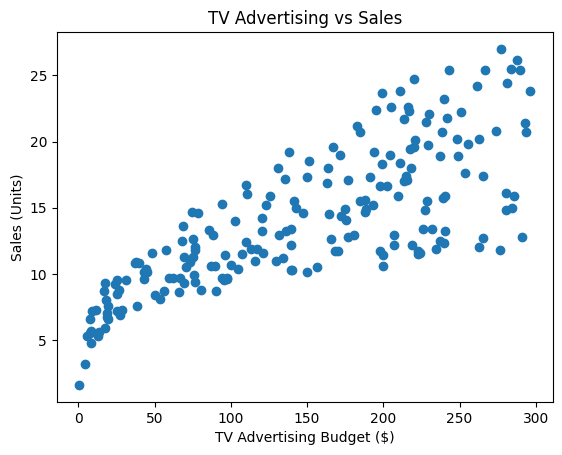

In [17]:
plt.figure()

plt.scatter(df["TV Ad Budget ($)"], df["Sales(Units)"])

plt.xlabel("TV Advertising Budget ($)")
plt.ylabel("Sales (Units)")
plt.title("TV Advertising vs Sales")

plt.show()

## Radio Advirtising Vs. Sales

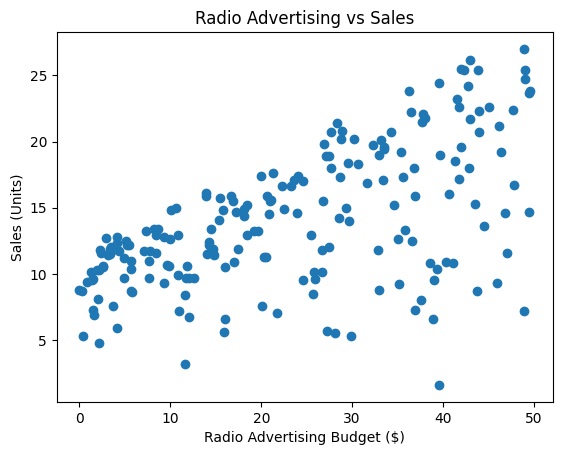

In [18]:
plt.figure()

plt.scatter(df["Radio Ad Budget ($)"], df["Sales(Units)"])

plt.xlabel("Radio Advertising Budget ($)")
plt.ylabel("Sales (Units)")
plt.title("Radio Advertising vs Sales")

plt.show()

## Newspaper advirtising Vs. Sales

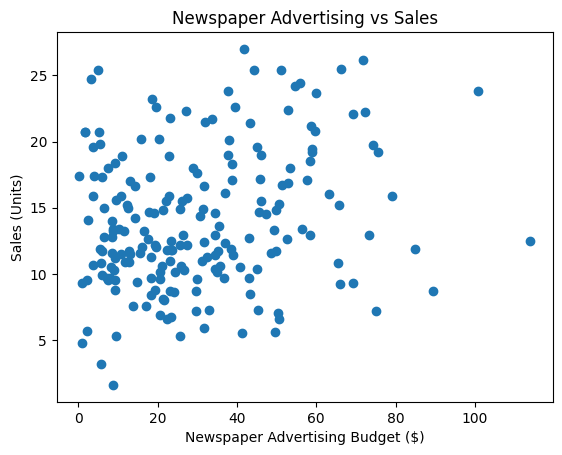

In [19]:
plt.figure()

plt.scatter(df["Newspaper Ad Budget ($)"], df["Sales(Units)"])

plt.xlabel("Newspaper Advertising Budget ($)")
plt.ylabel("Sales (Units)")
plt.title("Newspaper Advertising vs Sales")

plt.show()

explanation:

The exploratory analysis suggests that TV advertising has the strongest relationship with sales, followed by radio advertising. Newspaper advertising appears to have a weaker relationship with sales. This suggests that TV and radio advertising may be more important predictors when building a sales prediction model.

## Tv spend level

In [26]:
df["TV_spend_level"] = pd.qcut(
    df["TV Ad Budget ($)"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),TV_Share(%),Radio_Share(%),Newspaper_Share(%),Sales_per_Dollar,Total_Ad_Budget,Sales(Units),TV_spend_level
0,230.1,37.8,69.2,68.26,11.21,20.53,0.065559,337.1,22.1,High
1,44.5,39.3,45.1,34.52,30.49,34.99,0.080683,128.9,10.4,Low
2,17.2,45.9,69.3,12.99,34.67,52.34,0.070242,132.4,9.3,Low
3,151.5,41.3,58.5,60.29,16.43,23.28,0.073617,251.3,18.5,Medium
4,180.8,10.8,58.4,72.32,4.32,23.36,0.051600,250.0,12.9,Medium


I decided to try and see if making levels for spending will help any analysis I do.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["TV Ad Budget ($)", "Radio Ad Budget ($)", "Newspaper Ad Budget ($)"]]
y = df["Sales(Units)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))


R2 Score: 0.899438024100912
MAE: 1.4607567168117603


explanation:

The initial linear regression model was created for the prediction of sales using advertising budgets for TV, radio, and newspaper advertising channels. The initial linear regression model showed a good R² value, implying that advertising spending was the major driver of sales. Among the advertising channels, the TV advertising channel was the most influential for the predicted sales. The least influential advertising channel was the newspaper advertising channel.

